In [1]:
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore') 

load_dotenv()

True

In [2]:
import os
import urllib.parse
from sqlalchemy import create_engine

connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    f"SERVER={os.environ['SQL_SERVER']};"
    "DATABASE=customerChurnDB;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

connection_url = (
    "mssql+pyodbc:///?odbc_connect="
    + urllib.parse.quote_plus(connection_string)
)

engine = create_engine(connection_url)

In [4]:
test_df = pd.read_sql_query(
    "SELECT TOP 5 * FROM dbo.CustomerChurn",
    engine
)

test_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0002-ORFBO,Female,False,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,No
1,0003-MKNFE,Male,False,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,No
2,0004-TLHLJ,Male,False,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes
3,0011-IGKFF,Male,True,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes
4,0013-EXCHZ,Female,True,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,Yes


In [5]:
data = pd.read_sql_query(
    "Select * from dbo.CustomerChurn",
    engine
)

In [6]:
data.shape

(7043, 21)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   bool   
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
data.isna().mean()

customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
TotalCharges        0.001562
Churn               0.000000
dtype: float64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='TotalCharges', ylabel='Density'>

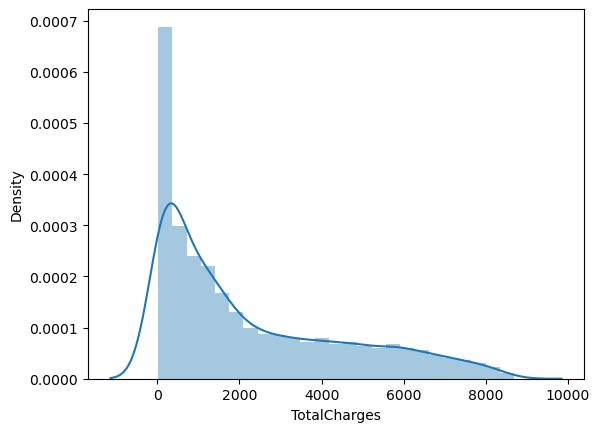

In [10]:
sns.distplot(data['TotalCharges'])

In [11]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
target_feature = 'Churn'
numerical_features = ['MonthlyCharges', 'TotalCharges', 'tenure']
categorical_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod'
]

In [13]:
X = data[numerical_features + categorical_features]
y = data[target_feature]

In [14]:
X.shape, y.shape

((7043, 19), (7043,))

### Data Preprocessing

In [15]:
from collections import Counter
Counter(y)

Counter({'No': 5174, 'Yes': 1869})

<b>This shows the data is imbalance as it is not distributed equally</b>

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)  #stratify split the train and test in the similar ratio of the output

<b>This stratify ensures the ratio of yes and no in train and test is same as y</b>

In [17]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.fit_transform(y_test)

In [18]:
y_test

array([1, 0, 1, ..., 0, 0, 0], shape=(2113,))

In [19]:
print(f"Training Dataset churn rate {y_train.mean():.2f}")
print(f"Testing Dataset churn rate {y_test.mean():.2f}")

Training Dataset churn rate 0.27
Testing Dataset churn rate 0.27


### Creating Pipeline

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [21]:
numerical_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

target_transformer = Pipeline(steps=[
    ('label', LabelEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('category', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced'
    ))
])

In [22]:
clf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('category', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
y_pred = clf_pipeline.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, recall_score, classification_report, roc_curve, auc

In [25]:
accuracy_score(y_test, y_pred)

0.73450070989115

In [26]:
precision_score(y_test, y_pred)

0.5

In [27]:
f1_score(y_test, y_pred)

0.6154900616860863

In [28]:
recall_score(y_test, y_pred)

0.8003565062388592

In [29]:
confusion_matrix(y_test, y_pred)

array([[1103,  449],
       [ 112,  449]])

In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1552
           1       0.50      0.80      0.62       561

    accuracy                           0.73      2113
   macro avg       0.70      0.76      0.71      2113
weighted avg       0.80      0.73      0.75      2113



In [31]:
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
roc_auc

0.8406254019883491

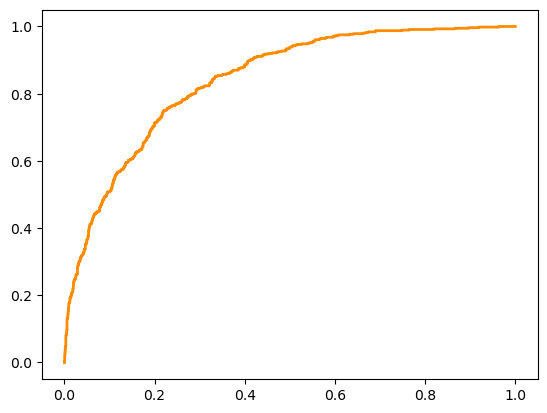

In [32]:
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

In [35]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('category', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,-1]

In [37]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1552
           1       0.61      0.47      0.53       561

    accuracy                           0.78      2113
   macro avg       0.72      0.68      0.69      2113
weighted avg       0.77      0.78      0.77      2113



In [38]:
confusion_matrix(y_test, y_pred_rf)

array([[1385,  167],
       [ 298,  263]])

In [39]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    clf_pipeline, X_train, y_train,
    scoring='roc_auc',
    cv=5
)

print("Logistic Regression CV AUC ", cv_auc.mean())

Logistic Regression CV AUC  0.8463788146061841


In [40]:
cv_auc = cross_val_score(
    rf_model, X_train, y_train,
    scoring='roc_auc',
    cv=5
)

print("Random Forest CV AUC ", cv_auc.mean())

Random Forest CV AUC  0.8211011412478104


### Hyperparameter Tuning

In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 5]
}

In [42]:
grid_rf = GridSearchCV(
    rf_model,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 5], 'model__min_samples_split': [2, 10], 'model__n_estimators': [200, 400]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('category', ...)]"


In [43]:
print("Best RF Params: ",grid_rf.best_params_)
print("Best RF CV AUC: ",grid_rf.best_score_)

Best RF Params:  {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Best RF CV AUC:  0.8455710810489082


In [44]:
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

y_pred_best_rf_prob = best_rf.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, threshold_rf = roc_curve(y_test, y_pred_best_rf_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)
print(accuracy_score(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf))

0.8414942710917546
0.7643161381921438
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1552
           1       0.54      0.75      0.63       561

    accuracy                           0.76      2113
   macro avg       0.72      0.76      0.73      2113
weighted avg       0.80      0.76      0.77      2113



In [45]:
accuracy_score(y_test, y_pred_best_rf)

0.7643161381921438

In [51]:
features_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature' : features_names,
    'importance' : importances
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

feat_imp.head(15)

,feature,importance
0,category__Contract_Month-to-month,0.135675
1,num__tenure,0.127758
2,num__TotalCharges,0.102387
3,num__MonthlyCharges,0.064655
4,category__Contract_Two year,0.060554
5,category__TechSupport_No,0.052191
6,category__OnlineSecurity_No,0.050422
7,category__InternetService_Fiber optic,0.041453
8,category__PaymentMethod_Electronic check,0.038741
9,category__Contract_One year,0.023738


<Axes: xlabel='importance', ylabel='feature'>

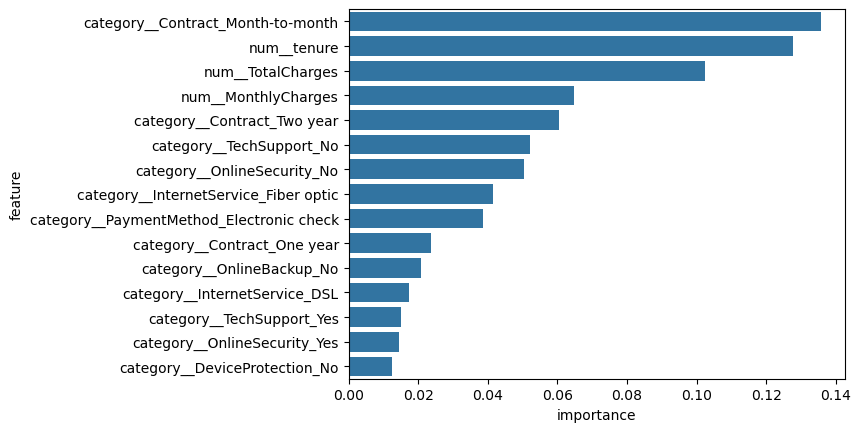

In [55]:
sns.barplot(data=feat_imp.head(15),y='feature',x='importance')

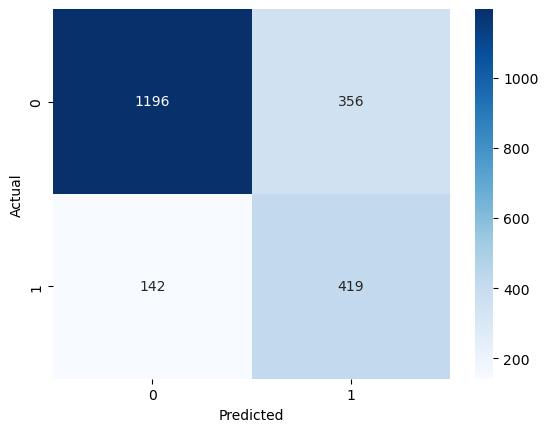

In [71]:
cm = confusion_matrix(y_test,y_pred_best_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [72]:
churn_pred = y_pred_best_rf_prob

risk_df = pd.DataFrame({
    "churn_probability" : churn_pred
})

risk_df['risk_level'] = pd.cut(
    risk_df['churn_probability'],
    bins=[0,0.3,0.6,1],
    labels=['low risk', 'medium risk', 'high risk']
)

risk_df['risk_level'].value_counts()

risk_level
low risk       977
high risk      610
medium risk    526
Name: count, dtype: int64

In [73]:
import joblib

joblib.dump(clf_pipeline, 'logistic_model.pkl')
joblib.dump(best_rf, 'rf_model.pkl')

['rf_model.pkl']

In [74]:
import sklearn
sklearn.__version__

'1.7.2'

In [ ]:
import shap
X_train_transformed = best_rf.named_steps['preprocessor'].transform(X_train)

In [77]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

In [78]:
rf_classifier = best_rf.named_steps['model']
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_train_transformed)

In [79]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[1].shape)
print(X_train_transformed.shape)

<class 'numpy.ndarray'>
4930
(46, 2)
(4930, 46)


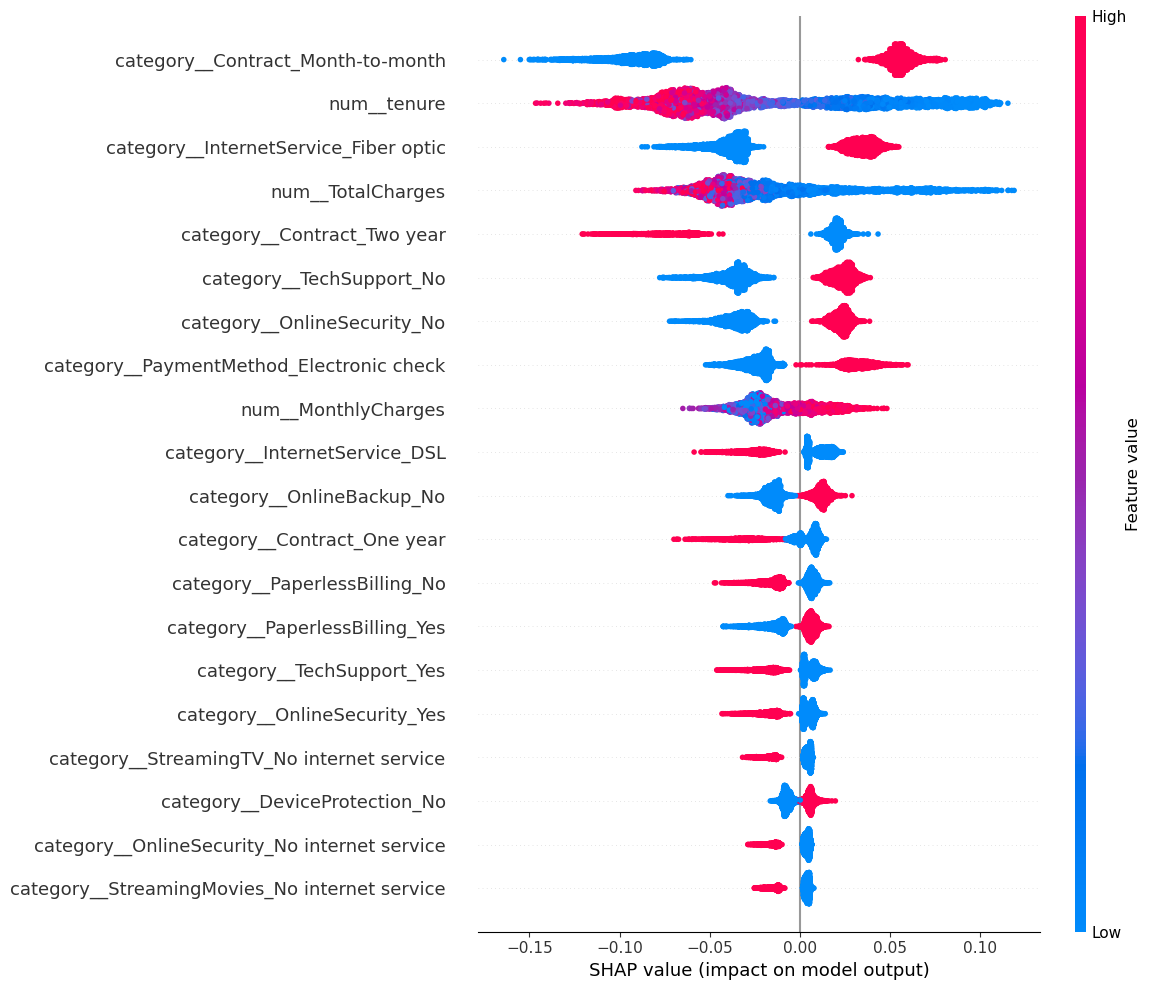

In [99]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names = feature_names,
    plot_size=(12, 10),
    show=False
)

plt.show()

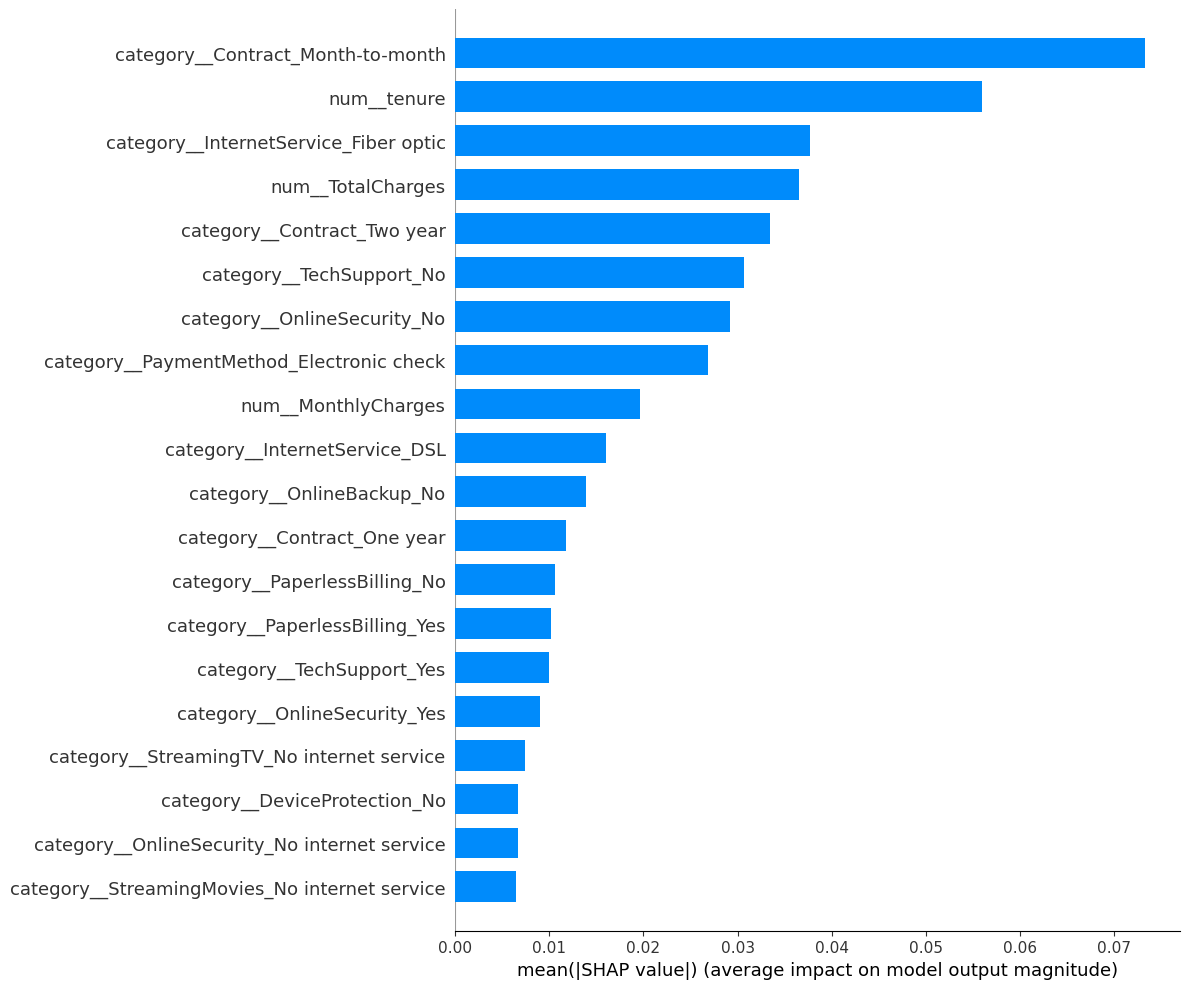

In [100]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names = feature_names,
    plot_type = 'bar',
    plot_size=(12, 10),
    show=False
)

plt.show()